# Analiza cyklicznego ściskania — krzywe naprężenie–odkształcenie i pole histerezy

Dane: pliki `820 dz-1.csv`, `820 dz-2.csv`, `820 dz-3.csv` — jeden ciągły pomiar z maszyny wytrzymałościowej (próbkowanie 100 Hz), pocięty przez oprogramowanie na części co 90 000 wierszy.

Kolumny: Czas [s], Siła [N], Przemieszczenie [mm], Naprężenie [N/mm² = MPa], Rozstaw [mm].

Cel:
1. Wykres σ–ε (stress [MPa] vs strain [%]) dla kolejnych cykli ściskania.
2. **Pole histerezy** każdego cyklu, czyli energia rozproszona w pętli obciążenie–odciążenie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

## 1. Wczytanie danych

Pliki są w kodowaniu Windows-1250, z przecinkiem dziesiętnym; pierwsze 3 wiersze to nagłówki (`aq`, nazwy kolumn, jednostki).

In [2]:
files = ['820 dz-1.csv', '820 dz-2.csv', '820 dz-3.csv']
cols = ['czas_s', 'sila_N', 'przemieszczenie_mm', 'naprezenie_MPa', 'rozstaw_mm']

df = pd.concat(
    [pd.read_csv(f, encoding='cp1250', skiprows=3, names=cols, decimal=',', quotechar='"') for f in files],
    ignore_index=True,
).sort_values('czas_s').reset_index(drop=True)

print(f'Liczba punktów: {len(df)}, czas: {df.czas_s.iloc[0]:.2f}–{df.czas_s.iloc[-1]:.2f} s')
df.head()

Liczba punktów: 199117, czas: 0.00–1991.16 s


,czas_s,sila_N,przemieszczenie_mm,naprezenie_MPa,rozstaw_mm
0,0.00,0.420094,0.0,0.002377,3.313499
1,0.01,0.417630,0.0,0.002363,3.313499
2,0.02,0.415802,0.0,0.002353,3.313499
3,0.03,0.414928,0.0,0.002348,3.313499
4,0.04,0.414610,0.0,0.002346,3.313499


## 2. Odkształcenie

Rozstaw płyt na początku pomiaru (przy przemieszczeniu 0) to wysokość początkowa próbki h₀.
Odkształcenie inżynierskie: ε = przemieszczenie / h₀ (dodatnie = ściskanie). Naprężenie maszyna podaje już w N/mm² (= MPa).

In [3]:
h0 = df['rozstaw_mm'].iloc[0]
df['strain'] = df['przemieszczenie_mm'] / h0          # odkształcenie [-]
df['strain_pct'] = df['strain'] * 100                  # [%]

print(f'h0 = {h0:.4f} mm')
print(f'maks. odkształcenie = {df.strain_pct.max():.1f} %')
print(f'maks. naprężenie    = {df.naprezenie_MPa.max():.4f} MPa')

h0 = 3.3135 mm
maks. odkształcenie = 90.1 %
maks. naprężenie    = 0.6867 MPa


## 3. Podział na cykle

Między cyklami trawersa odjeżdża od próbki (przemieszczenie ujemne, siła ≈ 0). Cykl = spójny odcinek, w którym przemieszczenie > 0 (kontakt z próbką).

In [4]:
PROG_MM = 0.02      # margines na szum wokół zera
MIN_PUNKTOW = 200   # odrzuć krótkie przypadkowe przejścia przez zero

w_kontakcie = (df['przemieszczenie_mm'] > PROG_MM).to_numpy()
zmiany = np.flatnonzero(np.diff(w_kontakcie.astype(int)))
granice = np.concatenate([[0], zmiany + 1, [len(df)]])

cykle = []
for a, b in zip(granice[:-1], granice[1:]):
    if w_kontakcie[a] and b - a >= MIN_PUNKTOW:
        cykle.append(df.iloc[a:b])

print(f'Wykryto cykli: {len(cykle)}')
for i, c in enumerate(cykle, 1):
    print(f'  cykl {i}: t = {c.czas_s.iloc[0]:7.1f}–{c.czas_s.iloc[-1]:7.1f} s, '
          f'F_max = {c.sila_N.max():7.2f} N, σ_max = {c.naprezenie_MPa.max():.4f} MPa')

Wykryto cykli: 6
  cykl 1: t =     0.7–   71.9 s, F_max =  106.86 N, σ_max = 0.6047 MPa
  cykl 2: t =   372.6–  443.7 s, F_max =  121.35 N, σ_max = 0.6867 MPa
  cykl 3: t =   744.4–  815.5 s, F_max =  117.16 N, σ_max = 0.6630 MPa
  cykl 4: t =  1116.2– 1187.3 s, F_max =  110.45 N, σ_max = 0.6250 MPa
  cykl 5: t =  1487.9– 1559.1 s, F_max =  109.45 N, σ_max = 0.6194 MPa
  cykl 6: t =  1859.7– 1930.9 s, F_max =  109.09 N, σ_max = 0.6173 MPa


## 4. Wykres naprężenie–odkształcenie dla wszystkich cykli

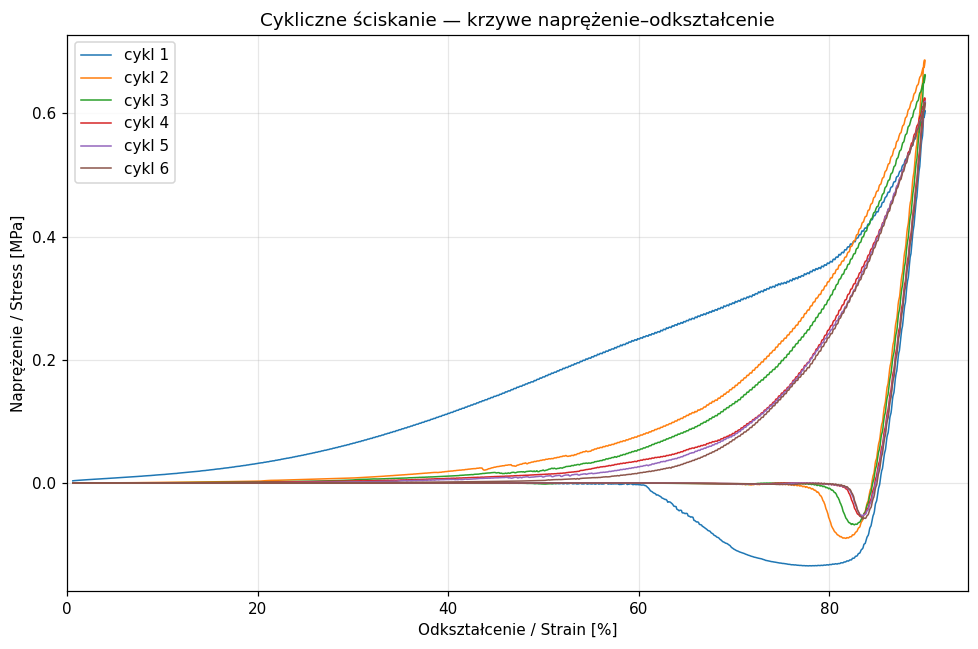

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
kolory = plt.cm.tab10(np.linspace(0, 1, 10))

for i, c in enumerate(cykle, 1):
    ax.plot(c['strain_pct'], c['naprezenie_MPa'], lw=1.0, color=kolory[i - 1], label=f'cykl {i}')

ax.set_xlabel('Odkształcenie / Strain [%]')
ax.set_ylabel('Naprężenie / Stress [MPa]')
ax.set_title('Cykliczne ściskanie — krzywe naprężenie–odkształcenie')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig('wykres_sigma_eps_cykle.png', dpi=200)
plt.show()

## 5. Pole histerezy

Pole pętli histerezy to całka po zamkniętej pętli W = ∮ σ dε — energia rozproszona w cyklu na jednostkę objętości próbki.
Liczona metodą trapezów wzdłuż całego przebiegu cyklu (obciążenie + odciążenie); gałąź obciążania daje wkład dodatni, odciążania ujemny, różnica = pole pętli.

Jednostki: σ [N/mm²] × ε [–] → **mJ/mm³ = MJ/m³** (w tabeli także kJ/m³).
Dodatkowo: praca z pętli siła–przemieszczenie [N·mm = mJ] oraz współczynnik dyssypacji = pole pętli / energia obciążania.

In [6]:
wyniki = []
for i, c in enumerate(cykle, 1):
    eps = c['strain'].to_numpy()
    sig = c['naprezenie_MPa'].to_numpy()
    d = c['przemieszczenie_mm'].to_numpy()
    F = c['sila_N'].to_numpy()

    i_max = int(np.argmax(eps))
    W_obc = np.trapezoid(sig[:i_max + 1], eps[:i_max + 1])        # energia obciążania [mJ/mm³]
    W_odc = -np.trapezoid(sig[i_max:], eps[i_max:])               # energia oddana przy odciążaniu
    W_petla = np.trapezoid(sig, eps)                              # pole pętli = W_obc - W_odc
    praca_mJ = np.trapezoid(F, d)                                 # pole pętli siła–przemieszczenie [mJ]

    wyniki.append({
        'cykl': i,
        'σ_max [MPa]': sig.max(),
        'ε_max [%]': eps.max() * 100,
        'pole histerezy [mJ/mm³]': W_petla,
        'pole histerezy [kJ/m³]': W_petla * 1000,
        'W obciążania [mJ/mm³]': W_obc,
        'W odciążania [mJ/mm³]': W_odc,
        'dyssypacja [%]': 100 * W_petla / W_obc,
        'praca pętli [N·mm]': praca_mJ,
    })

tabela = pd.DataFrame(wyniki).set_index('cykl')
tabela.round(4)

,σ_max [MPa],ε_max [%],pole histerezy [mJ/mm³],pole histerezy [kJ/m³],W obciążania [mJ/mm³],W odciążania [mJ/mm³],dyssypacja [%],praca pętli [N·mm]
cykl,,,,,,,,
1,0.6047,90.0785,0.1657,165.6935,0.1551,-0.0106,106.8110,97.0208
2,0.6867,90.0672,0.0799,79.8963,0.0932,0.0133,85.7561,46.7828
3,0.6630,90.0823,0.0675,67.4867,0.0814,0.0139,82.8995,39.5164
4,0.6250,90.0747,0.0529,52.8816,0.0662,0.0133,79.8604,30.9645
5,0.6194,90.0898,0.0505,50.5182,0.0636,0.0131,79.4388,29.5806
6,0.6173,90.0785,0.0472,47.1720,0.0598,0.0127,78.8472,27.6213


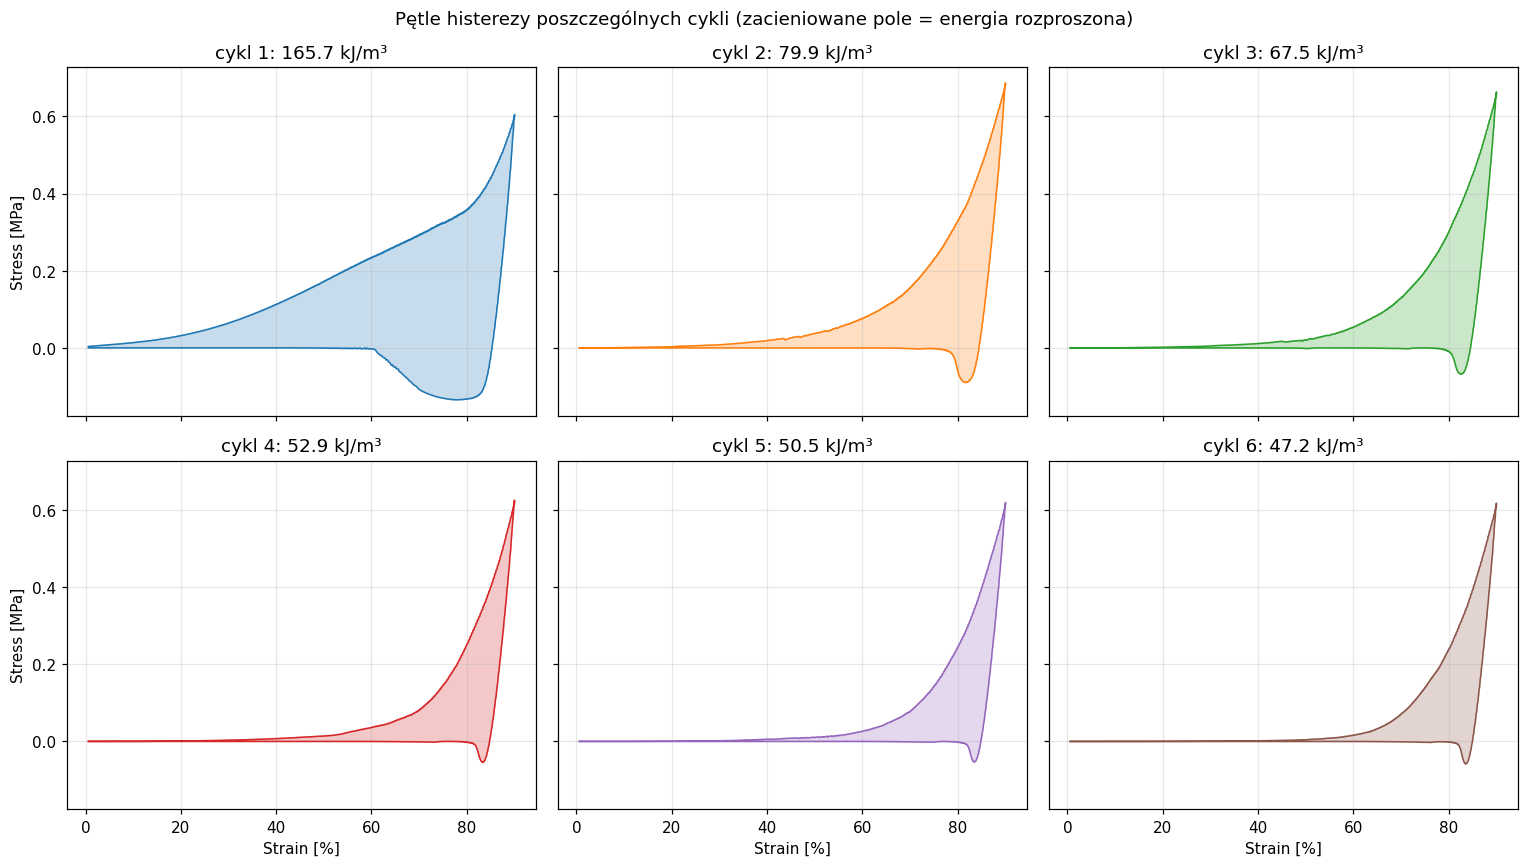

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, (i, c) in zip(axes.flat, enumerate(cykle, 1)):
    eps = c['strain_pct'].to_numpy()
    sig = c['naprezenie_MPa'].to_numpy()
    ax.fill(eps, sig, color=kolory[i - 1], alpha=0.25)
    ax.plot(eps, sig, color=kolory[i - 1], lw=1.0)
    W = tabela.loc[i, 'pole histerezy [kJ/m³]']
    ax.set_title(f'cykl {i}: {W:.1f} kJ/m³')
    ax.grid(alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('Strain [%]')
for ax in axes[:, 0]:
    ax.set_ylabel('Stress [MPa]')
fig.suptitle('Pętle histerezy poszczególnych cykli (zacieniowane pole = energia rozproszona)')
fig.tight_layout()
fig.savefig('petle_histerezy.png', dpi=200)
plt.show()

In [8]:
tabela.round(5).to_csv('wyniki_histereza.csv', encoding='utf-8-sig')
print('Zapisano: wyniki_histereza.csv, wykres_sigma_eps_cykle.png, petle_histerezy.png')

Zapisano: wyniki_histereza.csv, wykres_sigma_eps_cykle.png, petle_histerezy.png


## Uwagi metodyczne

- h₀ przyjęto jako rozstaw płyt na początku pomiaru (przemieszczenie = 0). Jeśli rzeczywista wysokość próbki była inna, wystarczy podmienić `h0` w sekcji 2 — naprężenia się nie zmienią, przeskaluje się tylko oś odkształcenia i wartości pola histerezy (liniowo).
- Pole histerezy w mJ/mm³ odnosi się do jednostki objętości; praca pętli w N·mm to energia całkowita rozproszona przez próbkę w danym cyklu (niezależna od h₀ i pola przekroju).
- Pierwszy cykl bywa „rozbiegowy” (efekt Mullinsa w elastomerach / osiadanie próbki) — zwykle ma inne pole niż kolejne, które się stabilizują.